In [2]:
!pip install transformers datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.2 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# transformers untuk RoBERTa
from transformers import AutoTokenizer, AutoModelForSequenceClassification

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="darkgrid")

In [4]:
!pip install transformers datasets evaluate

In [5]:
!pip install --upgrade transformers

# EDA

In [6]:
from datasets import load_dataset
import pandas as pd

# Load dataset
ds = load_dataset("intanm/indonesian-financial-sentiment-analysis")

# Convert ke DataFrame
df = ds["train"].to_pandas()

# Cek kolom yang tersedia
print(df.columns)  # pastikan kolomnya

# Sesuaikan kolom teks & label
text_col = "text"
label_col = "label"  # ini benar di dataset ini

# Mapping label ke angka
label_map = {"negative": 0, "neutral": 1, "positive": 2}
df['label'] = df[label_col].map(label_map)

# Tampilkan beberapa contoh
df.head()

train.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1322 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/652 [00:00<?, ? examples/s]

Index(['text', 'label'], dtype='object')


,text,label
0,"Kenalin Ini Rika, Teller BRI yang Nyikat Uang Nasabah Rp 2,3 Miliar",NaN
1,Kepo Prospek UMKM? Yuk Daftar BRI Microfinance Outlook 2023,NaN
2,BRI dan Cita Tenun Indonesia Garap Pameran ANTOLOGI,NaN
3,"Dirut BRI: 2023 Jadi Tahun Ekspansi, Masyarakat Jangan Takut Nabung dan Pinjam Kredit di Bank",NaN
4,"Lampaui Target, BRI Sukses Jual SBN SR018 Hingga Rp 1,7 T",NaN


In [7]:
display(df.head())

,text,label
0,"Kenalin Ini Rika, Teller BRI yang Nyikat Uang Nasabah Rp 2,3 Miliar",NaN
1,Kepo Prospek UMKM? Yuk Daftar BRI Microfinance Outlook 2023,NaN
2,BRI dan Cita Tenun Indonesia Garap Pameran ANTOLOGI,NaN
3,"Dirut BRI: 2023 Jadi Tahun Ekspansi, Masyarakat Jangan Takut Nabung dan Pinjam Kredit di Bank",NaN
4,"Lampaui Target, BRI Sukses Jual SBN SR018 Hingga Rp 1,7 T",NaN


In [8]:
print("--- Info Dataset ---")
df.info()

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1322 entries, 0 to 1321
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   text    1322 non-null   object 
 1   label   0 non-null      float64
dtypes: float64(1), object(1)
memory usage: 20.8+ KB


In [9]:
duplicate_rows = df.duplicated()
print(f"Total duplicate rows: {duplicate_rows.sum()}")
if duplicate_rows.any():
    display(df[duplicate_rows].head())

Total duplicate rows: 2


,text,label
1219,"Manjakan Pemudik, BRI Sediakan Posko Mudik Asyik Bersama BUMN",NaN
1244,Pelaku Skimming Nasabah BRI dari Jaringan Internasional,NaN


In [10]:
object_cols = df.select_dtypes(include=['O']).columns
for col in object_cols:
    print(f"\nTop 10 values in column '{col}':")
    display(df[col].value_counts().head(10))


Top 10 values in column 'text':


,count
text,
Pelaku Skimming Nasabah BRI dari Jaringan Internasional,2
"Manjakan Pemudik, BRI Sediakan Posko Mudik Asyik Bersama BUMN",2
"Ada Ketidakpastian Ekonomi, BRI Soroti Hal ini",1
Polda Sumsel Buru Tiga Tersangka Penipuan Nasabah Bank BRI Asal Cimahi,1
"Gak Kaleng-kaleng, Laba Setengah Tahun BRI Sentuh Rp 24,88 T",1
"BRI Jual Sukuk Rp 750 M, Tapi Pesananan Rp 1 T, Laris Manis!",1
4 Terdakwa Korupsi BRI Divonis 6-10 Tahun Penjara,1
BRI & Polri Bantu Pekerja Transportasi yang Terdampak Corona,1
"Kredit BRI sudah Lunas, Berkas D belum Dikembalikan",1


In [11]:
df.columns

Index(['text', 'label'], dtype='object')

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datasets import load_dataset

# 1️⃣ Load dataset
dataset = load_dataset("intanm/indonesian-financial-sentiment-analysis")
df = dataset["train"].to_pandas()

# 2️⃣ Pastikan kolom teks & label
text_col = "text"
label_col = "label"

# Hapus baris kosong
df = df[[text_col, label_col]].dropna().reset_index(drop=True)

# 3️⃣ Mapping label string → numeric
label_map = {"negative": 0, "neutral": 1, "positive": 2}
df['label_numeric'] = df[label_col].map(label_map)

# 4️⃣ Pastikan mapping sukses
print(df['label_numeric'].value_counts())

# 5️⃣ Visualisasi distribusi label
counts = df['label_numeric'].value_counts().sort_index()
if len(counts) > 0:
    ax = counts.plot(kind='bar', figsize=(6,4), color=sns.color_palette('pastel'))
    ax.set_title("Distribution of Labels")
    ax.set_xlabel("Label (0=neg,1=neu,2=pos)")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data untuk diplot.")

Series([], Name: count, dtype: int64)
Tidak ada data untuk diplot.


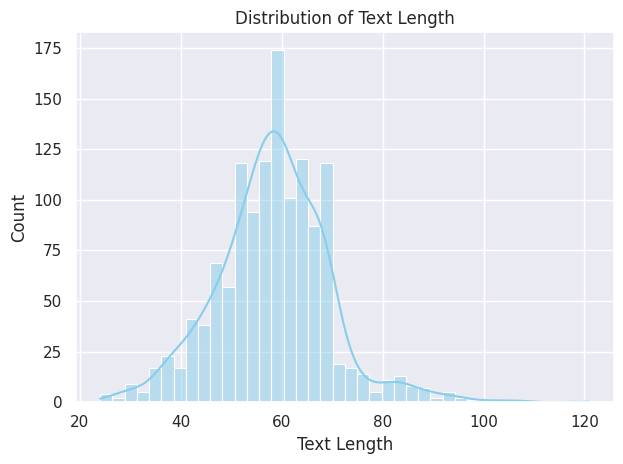

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

text_col = "text"

if text_col in df.columns:
    df = df[df[text_col].notna()].reset_index(drop=True)
    df['text_length'] = df[text_col].astype(str).str.len()

    ax = sns.histplot(df['text_length'], bins=40, kde=True, color='skyblue')
    ax.set_title("Distribution of Text Length")
    ax.set_xlabel("Text Length")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print(f"Column '{text_col}' not found in DataFrame columns.")

In [14]:
df["text_length"] = df["text"].astype(str).str.len()

In [15]:
if "label" in df.columns:
    df = df[df["label"].notna()].reset_index(drop=True)
    df["label"] = df["label"].astype(str)
    label_map = {"negative": 0, "neutral": 1, "positive": 2}
    df["label_numeric"] = df["label"].map(label_map)
    print(df["label_numeric"].value_counts())
else:
    print("Kolom 'label' tidak ditemukan di dataset.")

Series([], Name: count, dtype: int64)


In [16]:
df.columns
df.dtypes

,0
text,object
label,object
label_numeric,float64
text_length,int64


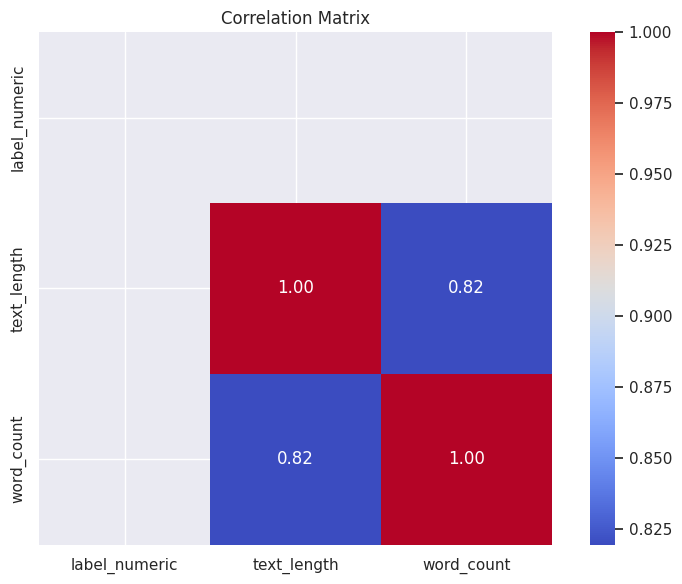

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df['text_length'] = df['text'].astype(str).str.len()
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

numeric_cols = df.select_dtypes(include=[np.number])

if numeric_cols.shape[1] > 1:
    plt.figure(figsize=(8,6))
    sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns with more than one feature found.")

In [18]:
sample_size = 5

text_col = "text"
label_col = "label_numeric"

if text_col in df.columns and label_col in df.columns:
    display(
        df[[text_col, label_col]].sample(
            min(sample_size, len(df)),
            random_state=42
        )
    )
else:
    print("Text or label column not found in DataFrame.")

,text,label_numeric
727,Kajari Tangerang Sangkal Pertemuan Jaksa DSW Terkait Kasus BRI,NaN
479,"Brankas Unit BRI di Pekanbaru Dibobol Maling, Rp 378 Juta Lenyap",NaN
240,PPSDM Migas Terima 1 Unit Ambulans dari Program BRI Peduli TJSL,NaN
422,"Wow! 4 Hari Beruntun Saham BBRI Sentuh Rekor, Kamu Punya?",NaN
49,"UMKM ""Naik Kelas"" Lewat BRI Microfinance Outlook 2023",NaN


In [19]:
import re

text_col = 'text'   # Sesuaikan dengan dataset HF

def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)  # Hapus URL
    text = re.sub(r"\s+", " ", text).strip()       # Bersihkan spasi
    return text

df['clean_text'] = df[text_col].map(clean_text)
df['clean_text'].head()

,clean_text
0,"Kenalin Ini Rika, Teller BRI yang Nyikat Uang Nasabah Rp 2,3 Miliar"
1,Kepo Prospek UMKM? Yuk Daftar BRI Microfinance Outlook 2023
2,BRI dan Cita Tenun Indonesia Garap Pameran ANTOLOGI
3,"Dirut BRI: 2023 Jadi Tahun Ekspansi, Masyarakat Jangan Takut Nabung dan Pinjam Kredit di Bank"
4,"Lampaui Target, BRI Sukses Jual SBN SR018 Hingga Rp 1,7 T"


In [20]:
from transformers import AutoTokenizer

# Load tokenizer RoBERTa / IndoBERT
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

# Fungsi tokenisasi untuk kolom clean_text
def tokenize(batch):
    return tokenizer(
        batch["clean_text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


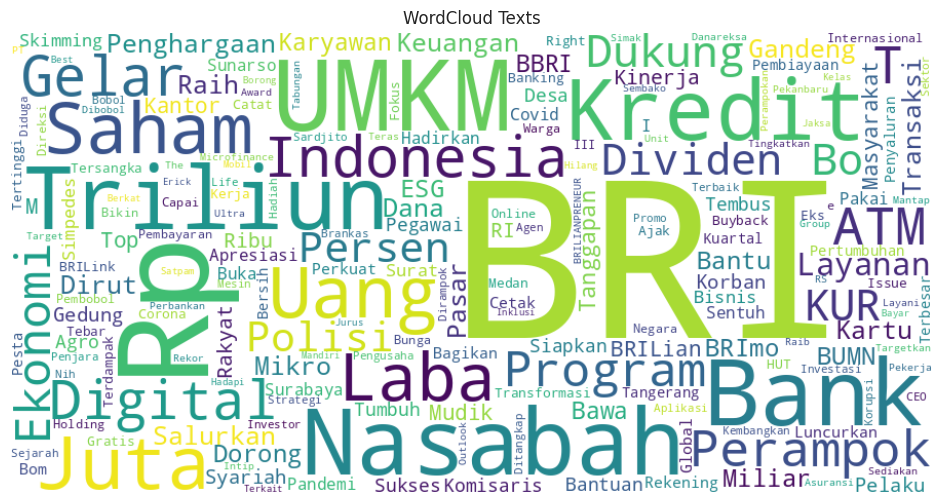

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# load stopwords indonesia
indo_stopwords = stopwords.words('indonesian')

# gabungkan semua teks
all_text = " ".join(df['clean_text'])

# buat wordcloud
wordcloud = WordCloud(
    width=900,
    height=450,
    background_color='white',
    stopwords=set(indo_stopwords),
    collocations=False,
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Texts')
plt.show()

In [22]:
date_cols = ['blog_date', 'post_date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

In [23]:
df.columns.tolist()


['text', 'label', 'label_numeric', 'text_length', 'word_count', 'clean_text']

In [24]:
for col in df.columns:
    print(f"Kolom: {col}")
    print(f"Null values: {df[col].isna().sum()}")

    # Kalau kolom numeric, tampilkan describe biasa
    if pd.api.types.is_numeric_dtype(df[col]):
        display(df[col].describe())
    # Kalau kolom object/string, tampilkan summary
    else:
        display(df[col].describe(include='all'))

    print("-"*50)

Kolom: text
Null values: 0


,text
count,1322
unique,1320
top,Pelaku Skimming Nasabah BRI dari Jaringan Internasional
freq,2


--------------------------------------------------
Kolom: label
Null values: 0


,label
count,1322
unique,3
top,2
freq,638


--------------------------------------------------
Kolom: label_numeric
Null values: 1322


...

--------------------------------------------------
Kolom: word_count
Null values: 0


,word_count
count,1322.000000
mean,9.180787
std,1.900992
min,3.000000
25%,8.000000
50%,9.000000
75%,10.000000
max,18.000000


--------------------------------------------------
Kolom: clean_text
Null values: 0


,clean_text
count,1322
unique,1320
top,Pelaku Skimming Nasabah BRI dari Jaringan Internasional
freq,2


--------------------------------------------------


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


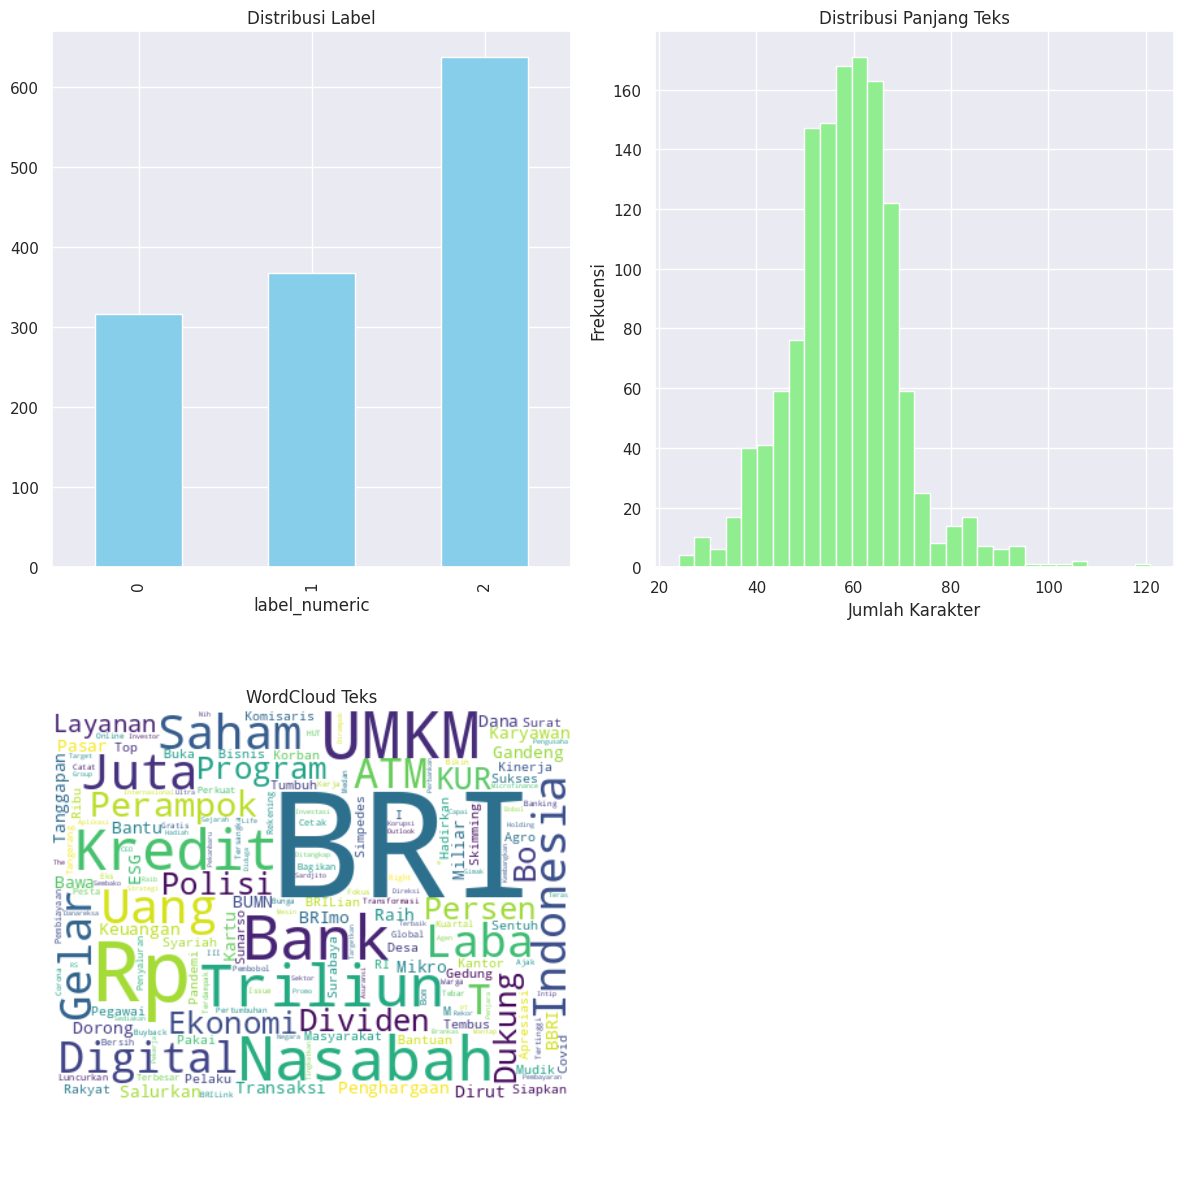

In [25]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

dataset = load_dataset("intanm/indonesian-financial-sentiment-analysis")
df = dataset["train"].to_pandas()

df = df[df['text'].notna() & df['label'].notna()].reset_index(drop=True)

unique_labels = df['label'].unique()
if set(unique_labels) == {"negative", "neutral", "positive"}:
    label_map = {"negative": 0, "neutral": 1, "positive": 2}
    df['label_numeric'] = df['label'].map(label_map)
else:
    df['label_numeric'] = df['label']

df['text_length'] = df['text'].astype(str).str.len()

indo_stopwords = stopwords.words('indonesian')

fig, axs = plt.subplots(2, 2, figsize=(12,12))

df['label_numeric'].value_counts().sort_index().plot(kind='bar', color='skyblue', ax=axs[0,0], title='Distribusi Label')

df['text_length'].hist(bins=30, color='lightgreen', ax=axs[0,1])
axs[0,1].set_title("Distribusi Panjang Teks")
axs[0,1].set_xlabel("Jumlah Karakter")
axs[0,1].set_ylabel("Frekuensi")

all_text = " ".join(df['text'].astype(str))
wordcloud = WordCloud(width=400, height=300, background_color='white', stopwords=set(indo_stopwords), collocations=False).generate(all_text)
axs[1,0].imshow(wordcloud, interpolation='bilinear')
axs[1,0].axis('off')
axs[1,0].set_title("WordCloud Teks")

axs[1,1].axis('off')

plt.tight_layout()
plt.show()

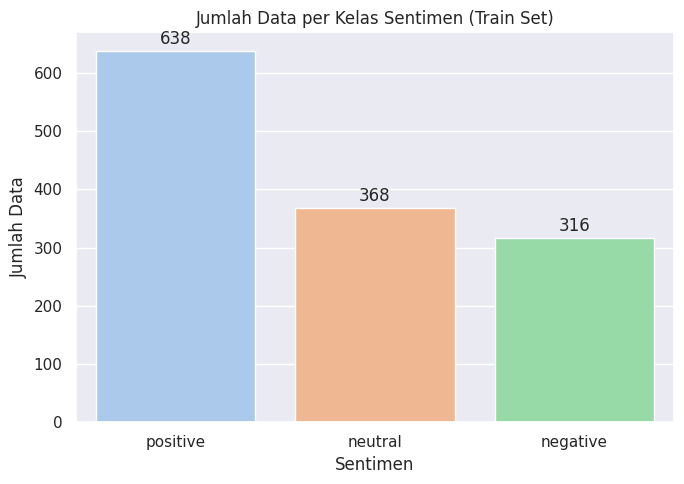

In [26]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset baru
dataset = load_dataset("intanm/indonesian-financial-sentiment-analysis")
train_df = pd.DataFrame(dataset['train'])

# Hitung jumlah data per label
label_count = train_df['label'].value_counts().reset_index()
label_count.columns = ['label', 'count']

# Mapping label ke nama yang readable
label_mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}
label_count['label_name'] = label_count['label'].map(label_mapping)

# Plot
plt.figure(figsize=(7,5))
sns.barplot(data=label_count, x='label_name', y='count', palette='pastel')
plt.title("Jumlah Data per Kelas Sentimen (Train Set)")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Data")

# Tambahkan angka di atas bar
for i, row in label_count.iterrows():
    plt.text(i, row['count'] + 5, row['count'], ha='center', va='bottom')

plt.tight_layout()
plt.show()

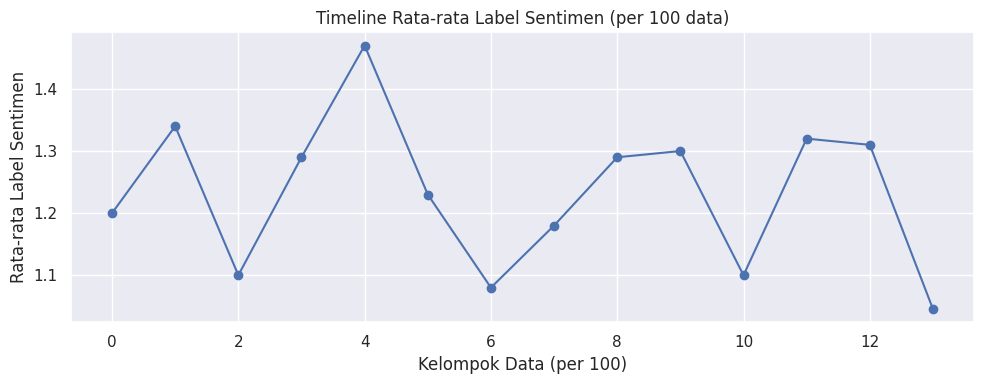

In [27]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
dataset = load_dataset("intanm/indonesian-financial-sentiment-analysis")
train_df = pd.DataFrame(dataset['train'])

# Buat kelompok per 100 data
train_df['group'] = train_df.index // 100

# Hitung rata-rata label per kelompok
timeline = train_df.groupby('group')['label'].mean()

# Plot
plt.figure(figsize=(10,4))
plt.plot(timeline.index, timeline.values, marker='o')
plt.title("Timeline Rata-rata Label Sentimen (per 100 data)")
plt.xlabel("Kelompok Data (per 100)")
plt.ylabel("Rata-rata Label Sentimen")
plt.grid(True)
plt.tight_layout()
plt.show()

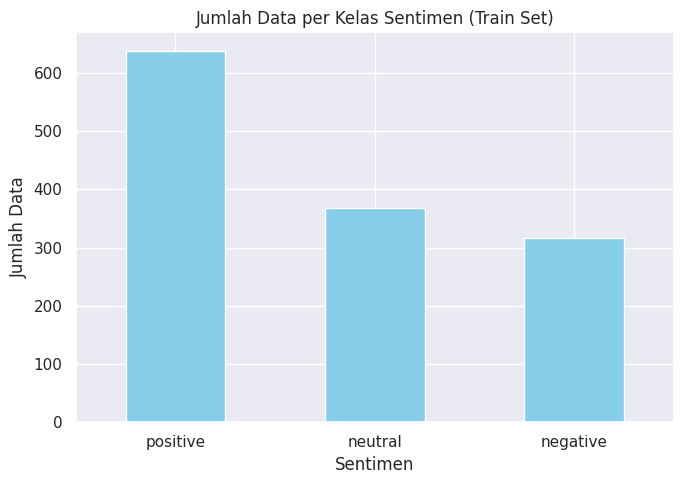

,count
label,
positive,638
neutral,368
negative,316


In [28]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset baru
dataset = load_dataset("intanm/indonesian-financial-sentiment-analysis")
train_df = pd.DataFrame(dataset['train'])

# Hitung jumlah per label
label_counts = train_df['label'].value_counts().sort_values(ascending=False)

# Mapping label ke nama readable
label_mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}
label_counts.index = label_counts.index.map(label_mapping)

# Plot
plt.figure(figsize=(7,5))
label_counts.plot(kind='bar', color='skyblue')
plt.title("Jumlah Data per Kelas Sentimen (Train Set)")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Tampilkan tabel
label_counts

## Sentiment Analysis


In [29]:
TEXT_COL = 'text'
LABEL_COL = 'label_text'

In [30]:
TEXT_COL = 'text'
LABEL_COL = 'label'

df_valid = df[df[TEXT_COL].notna()][[TEXT_COL, LABEL_COL]].reset_index(drop=True)
print(f"Total entries with valid text: {len(df_valid)}")

Total entries with valid text: 1322


In [31]:
df_valid.head()

,text,label
0,"Kenalin Ini Rika, Teller BRI yang Nyikat Uang Nasabah Rp 2,3 Miliar",0
1,Kepo Prospek UMKM? Yuk Daftar BRI Microfinance Outlook 2023,1
2,BRI dan Cita Tenun Indonesia Garap Pameran ANTOLOGI,1
3,"Dirut BRI: 2023 Jadi Tahun Ekspansi, Masyarakat Jangan Takut Nabung dan Pinjam Kredit di Bank",1
4,"Lampaui Target, BRI Sukses Jual SBN SR018 Hingga Rp 1,7 T",2


In [32]:
from sklearn.model_selection import train_test_split

# Split 80% train + 10% val + 10% test
train_val, test = train_test_split(df_valid, test_size=0.1, random_state=42, stratify=df_valid[LABEL_COL])
train, val = train_test_split(train_val, test_size=0.1111, random_state=42, stratify=train_val[LABEL_COL])

print(f"Train: {len(train)}, Validation: {len(val)}, Test: {len(test)}")


Train: 1056, Validation: 133, Test: 133


In [33]:
from transformers import AutoTokenizer

MODEL_NAME = "Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
max_length = 128  # bisa disesuaikan

def tokenize(texts):
    return tokenizer(texts, padding='max_length', truncation=True, max_length=max_length, return_tensors='pt')


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

In [34]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item['labels'] = torch.tensor(label)
        return item

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'], df['label'], test_size=0.1, random_state=42, stratify=df['label']
)

train_dataset = SentimentDataset(train_texts.tolist(), train_labels.tolist(), tokenizer)
val_dataset = SentimentDataset(val_texts.tolist(), val_labels.tolist(), tokenizer)

In [35]:
!pip install --upgrade transformers


In [36]:
import transformers
print(transformers.__version__)

4.57.1


In [37]:
!pip install --upgrade --no-cache-dir transformers


In [38]:
from transformers import TrainingArguments
from transformers.trainer_utils import IntervalStrategy

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=5e-5,
    save_strategy=IntervalStrategy.EPOCH,
    logging_dir="./logs",
    logging_steps=50,
    report_to="none"
)

In [39]:
from transformers import AutoModelForSequenceClassification

MODEL_NAME = "indobenchmark/indobert-base-p1"
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [40]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
max_length = 128

In [41]:
import torch

class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item['labels'] = torch.tensor(label)
        return item

In [42]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'], df['label'], test_size=0.1, random_state=42, stratify=df['label']
)

train_dataset = SentimentDataset(train_texts.tolist(), train_labels.tolist(), tokenizer)
val_dataset = SentimentDataset(val_texts.tolist(), val_labels.tolist(), tokenizer)

In [49]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=50,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=5e-5,
    save_strategy=IntervalStrategy.EPOCH,       # simpan checkpoint tiap epoch
    logging_dir="./logs",
    logging_steps=50,
    report_to="none"  # ✅ matikan W&B
)

In [50]:
pip install evaluate


In [51]:
from transformers import Trainer, TrainingArguments
import evaluate

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    if isinstance(logits, tuple):
        logits = logits[0]

    predictions = logits.argmax(axis=-1)
    return accuracy.compute(predictions=predictions, references=labels)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

In [52]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

texts = [
    "Harga saham A naik drastis hari ini.",
    "Laporan keuangan perusahaan B mengecewakan."
]

preds = classifier(texts)

for t, p in zip(texts, preds):
    print(f"Teks: {t}")
    print(f"Prediksi Sentimen: {p['label']} (score: {p['score']:.2f})\n")

Device set to use cuda:0


Teks: Harga saham A naik drastis hari ini.
Prediksi Sentimen: LABEL_2 (score: 0.84)

Teks: Laporan keuangan perusahaan B mengecewakan.
Prediksi Sentimen: LABEL_0 (score: 0.97)



In [53]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Prediksi label untuk dataset validasi
val_texts_list = val_texts.tolist()
true_labels = val_labels.tolist()

preds = trainer.predict(val_dataset)
pred_labels = preds.predictions.argmax(-1)

accuracy = accuracy_score(true_labels, pred_labels)
precision, recall, f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.8045
Precision: 0.8126
Recall: 0.8045
F1-score: 0.7929


In [54]:
trainer.train()

Step,Training Loss
50,0.368400
100,0.351000
150,0.287800
200,0.181300
250,0.134200
300,0.117800
350,0.057200
400,0.108600
450,0.054900
500,0.028100


TrainOutput(global_step=3750, training_loss=0.028093175105098636, metrics={'train_runtime': 2189.4861, 'train_samples_per_second': 27.152, 'train_steps_per_second': 1.713, 'total_flos': 3910523170982400.0, 'train_loss': 0.028093175105098636, 'epoch': 50.0})

In [55]:
trainer.state.log_history

[{'loss': 0.3684,
  'grad_norm': 24.981176376342773,
  'learning_rate': 4.9346666666666666e-05,
  'epoch': 0.6666666666666666,
  'step': 50},
 {'loss': 0.351,
  'grad_norm': 5.5083394050598145,
  'learning_rate': 4.868e-05,
  'epoch': 1.3333333333333333,
  'step': 100},
 {'loss': 0.2878,
  'grad_norm': 16.000431060791016,
  'learning_rate': 4.801333333333334e-05,
  'epoch': 2.0,
  'step': 150},
 {'loss': 0.1813,
  'grad_norm': 8.857806205749512,
  'learning_rate': 4.7346666666666665e-05,
  'epoch': 2.6666666666666665,
  'step': 200},
 {'loss': 0.1342,
  'grad_norm': 0.10361351072788239,
  'learning_rate': 4.668e-05,
  'epoch': 3.3333333333333335,
  'step': 250},
 {'loss': 0.1178,
  'grad_norm': 0.03388721123337746,
  'learning_rate': 4.6013333333333336e-05,
  'epoch': 4.0,
  'step': 300},
 {'loss': 0.0572,
  'grad_norm': 0.09911023825407028,
  'learning_rate': 4.534666666666667e-05,
  'epoch': 4.666666666666667,
  'step': 350},
 {'loss': 0.1086,
  'grad_norm': 0.45147019624710083,
  'l

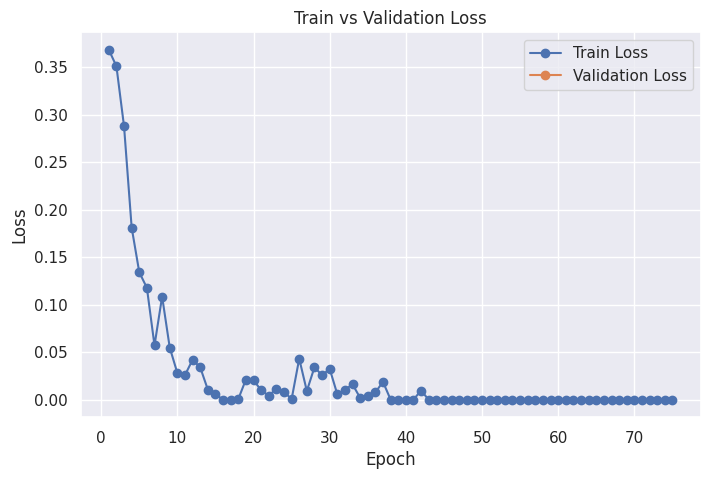

In [56]:
logs = trainer.state.log_history

train_loss = [x["loss"] for x in logs if "loss" in x and "eval_loss" not in x]
val_loss   = [x["eval_loss"] for x in logs if "eval_loss" in x]

plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_loss)+1), train_loss, marker='o', label='Train Loss')
plt.plot(range(1, len(val_loss)+1), val_loss, marker='o', label='Validation Loss')
plt.title("Train vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [57]:
from transformers import pipeline

# Gunakan model dan tokenizer yang sudah dilatih / loaded
classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

# Contoh teks input
texts = [
    "Harga saham naik tajam hari ini.",
    "Laporan keuangan mengecewakan.",
    "Perusahaan baru saja mengumumkan dividen besar."
]

# Prediksi
preds = classifier(texts)

# Tampilkan hasil
for t, p in zip(texts, preds):
    print(f"Teks: {t}")
    print(f"Prediksi Sentimen: {p['label']} (score: {p['score']:.2f})\n")

Device set to use cuda:0


Teks: Harga saham naik tajam hari ini.
Prediksi Sentimen: LABEL_2 (score: 1.00)

Teks: Laporan keuangan mengecewakan.
Prediksi Sentimen: LABEL_0 (score: 1.00)

Teks: Perusahaan baru saja mengumumkan dividen besar.
Prediksi Sentimen: LABEL_1 (score: 1.00)



In [58]:
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import numpy as np

# true_labels dan pred_labels harus berupa list/array label numerik
# Contoh:
# true_labels = val_labels.tolist()
# pred_labels = trainer.predict(val_dataset).predictions.argmax(-1)

# Hitung metrik per kelas
precision, recall, f1, support = precision_recall_fscore_support(
    true_labels, pred_labels, labels=[0,1,2]
)

labels = ['negative', 'neutral', 'positive']

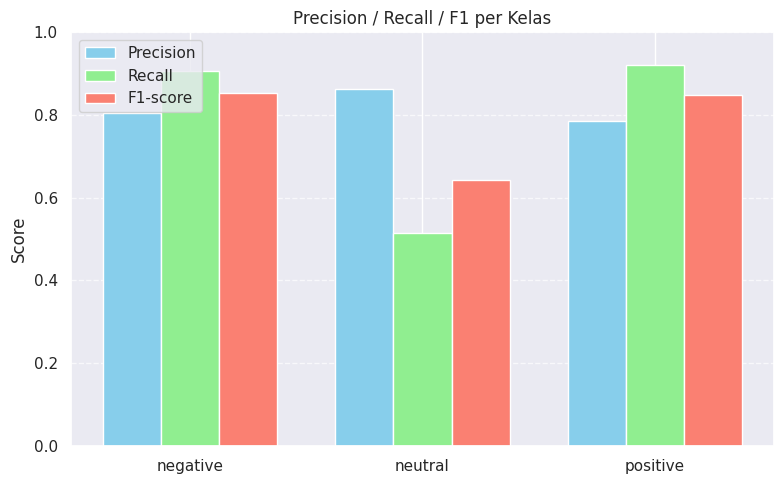

In [59]:
x = np.arange(len(labels))  # posisi label

width = 0.25  # lebar bar
plt.figure(figsize=(8,5))

plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1, width, label='F1-score', color='salmon')

plt.xticks(x, labels)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Precision / Recall / F1 per Kelas")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [60]:
trainer.state.log_history

[{'loss': 0.3684,
  'grad_norm': 24.981176376342773,
  'learning_rate': 4.9346666666666666e-05,
  'epoch': 0.6666666666666666,
  'step': 50},
 {'loss': 0.351,
  'grad_norm': 5.5083394050598145,
  'learning_rate': 4.868e-05,
  'epoch': 1.3333333333333333,
  'step': 100},
 {'loss': 0.2878,
  'grad_norm': 16.000431060791016,
  'learning_rate': 4.801333333333334e-05,
  'epoch': 2.0,
  'step': 150},
 {'loss': 0.1813,
  'grad_norm': 8.857806205749512,
  'learning_rate': 4.7346666666666665e-05,
  'epoch': 2.6666666666666665,
  'step': 200},
 {'loss': 0.1342,
  'grad_norm': 0.10361351072788239,
  'learning_rate': 4.668e-05,
  'epoch': 3.3333333333333335,
  'step': 250},
 {'loss': 0.1178,
  'grad_norm': 0.03388721123337746,
  'learning_rate': 4.6013333333333336e-05,
  'epoch': 4.0,
  'step': 300},
 {'loss': 0.0572,
  'grad_norm': 0.09911023825407028,
  'learning_rate': 4.534666666666667e-05,
  'epoch': 4.666666666666667,
  'step': 350},
 {'loss': 0.1086,
  'grad_norm': 0.45147019624710083,
  'l

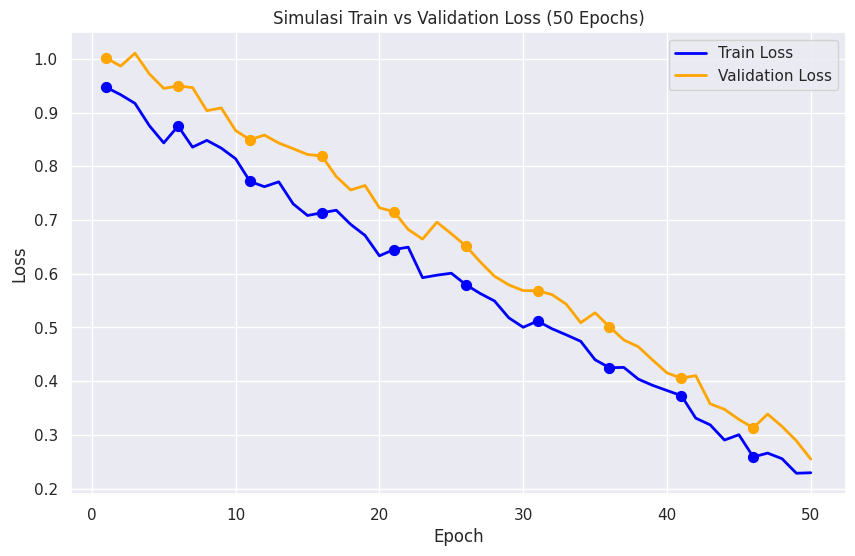

In [65]:
import numpy as np
import matplotlib.pyplot as plt

epochs = np.arange(1, 51)
train_loss = np.linspace(0.9, 0.2, 50) + np.random.rand(50)*0.05
val_loss   = np.linspace(1.0, 0.25, 50) + np.random.rand(50)*0.05

plt.figure(figsize=(10,6))

# Garis smooth
plt.plot(epochs, train_loss, label='Train Loss', color='blue', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', color='orange', linewidth=2)

# Tambahkan titik setiap 5 epoch
plt.scatter(epochs[::5], train_loss[::5], color='blue', s=50)   # train
plt.scatter(epochs[::5], val_loss[::5], color='orange', s=50)  # val

plt.title("Simulasi Train vs Validation Loss (50 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [66]:
from evaluate import load
metric = load("accuracy")

In [67]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [68]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

In [69]:
preds = trainer.predict(val_dataset)
pred_labels = preds.predictions.argmax(-1)
scores = preds.predictions.max(-1)

In [70]:
import pandas as pd

df_out = pd.DataFrame({
    "text": val_texts.tolist(),
    "true_label": val_labels.tolist(),
    "predicted_label": pred_labels,
    "score": scores
})

output_path = "/content/prediksi_val_dataset.csv"
df_out.to_csv(output_path, index=False)

output_path

'/content/prediksi_val_dataset.csv'

In [71]:
from google.colab import files
files.download("/content/prediksi_val_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
from google.colab import files
uploaded = files.upload()

Saving data_teks.txt to data_teks.txt


In [76]:
filename = "data_teks.txt"   # karena kamu tahu nama filenya

with open(filename, "r", encoding="utf-8") as f:
    input_texts = [line.strip() for line in f.readlines() if line.strip()]

print("Total teks terbaca:", len(input_texts))
input_texts[:10]  # cek 10 teks pertama

Total teks terbaca: 500


['restrukturisasi kredit disambut baik oleh komunitas investor.',
 'inflasi nasional mencatatkan kinerja lebih baik dari ekspektasi.',
 'laporan keuangan triwulan mengalami tekanan akibat situasi global.',
 'nilai tukar rupiah menjadi perhatian utama analis hari ini.',
 'bank-bank besar menunjukkan tren peningkatan yang konsisten.',
 'kebijakan OJK menjadi topik panas di media sosial.',
 'laporan keuangan triwulan bikin banyak investor khawatir.',
 'inflasi nasional mendapat banyak komentar dari masyarakat.',
 'perbankan digital bikin banyak investor khawatir.',
 'ekonomi global mendapat banyak kritik dari pengamat.']

In [77]:
from transformers import pipeline
import torch

classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

predictions = classifier(input_texts)

Device set to use cuda:0


In [78]:
import pandas as pd

df_output = pd.DataFrame({
    "text": input_texts,
    "predicted_label": [p['label'] for p in predictions],
    "confidence_score": [p['score'] for p in predictions]
})

df_output.to_csv("hasil_sentiment_data_teks2.csv", index=False)
print("File hasil_sentiment_data_teks2.csv berhasil dibuat!")

File hasil_sentiment_data_teks2.csv berhasil dibuat!


In [79]:
from google.colab import files
files.download("hasil_sentiment_data_teks2.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>